# Simulate Populations with Spontaneus Birth
## Part 2

We want to be able to use the simulation created in Part 1 of this notebook several times, and without manually running the simulation step-by-step. Let's keep the defintion for the simulation exactly the same as before, but create a wrapper that will allow the user to set how many (`n`) time steps to run the simulation. We also want to be able to show many (`r`) runs of the simulation on the same plot. 

The next two cells defining the simulation are taken from Part 1.

In [1]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import random

In [2]:
def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        
        self.population = []
        self.history =[]

    def __call__(self):
        self.population = [e() for e in self.population if not trial(self.death_chance)]
        self.population = self.population + (self.birth_rate * [entity()])
        self.history.append(len(self.population))

## Run the Simulation for `n` Periods `r` Number of Times and Visualize the Outcome

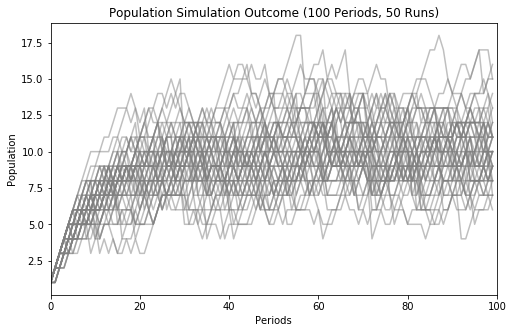

In [3]:
def run_sim(birth_rate, death_chance, n_periods, r_runs):
    """ Run simulation of environment for n periods and repeat r times, then plot the result"""

    # Set up plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Population Simulation Outcome ({n_periods} Periods, {r_runs} Runs)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(0, n_periods)
    )

    # Run simulation n times with r repeats.
    for r in range(r_runs):
        env = environment(birth_rate, death_chance)
        for period in range(0, n_periods):
            env()
        ax.plot(env.history, color=[.5, .5, .5, .5])

# Run the simulation
run_sim(1, .1, 100, 50)

## Conclusion

It becomes apparent that the population does indeed level off at an average population of around 10, but we observe a wide range of the population for any individual run of the simulation.

So far we have been simulating this population with a numerical model, next let's see if we can find an analytical solution.